# Day 9：用 Vibe Programming 做数据分析

这一章不再只讲某个 pandas 语法点，而是讲一种更接近真实工作的协作方式：**如何用自然语言驱动 AI，和你一起完成数据分析**。

前半部分先做概念导入，后半部分再落到一个更复杂的公开数据集上。

## 1. 学习目标

- 理解什么是 Vibe Programming，以及它为什么会改变数据分析的工作流。
- 了解截至 **2026-04-20** 常见的大模型和常见的 Agent 形态 / 框架。
- 掌握一套可复用的 Vibe Programming 基本步骤。
- 把这套方法应用到一个更复杂的在线公开数据集：UCI Bank Marketing。
- 学会在 AI 辅助分析中识别口径错误、样本不平衡和目标泄漏等风险。

## 2. 什么是 Vibe Programming

可以把 Vibe Programming 理解为：**你用自然语言描述目标、上下文和限制条件，AI 负责生成第一版思路、代码、图表和解释，而你负责验证、修正和最终判断**。

它不是“把编程交给 AI”，而是“把实现过程改造成一种高频迭代的人机协作”。

在数据分析场景里，Vibe Programming 常常表现为：

- 你先给出一个业务问题，例如“哪些客户更可能转化？”
- AI 帮你拆成几个可计算的问题，例如样本分布、缺失值、分组转化率、关键切片。
- AI 生成第一版 pandas / matplotlib / SQL 代码。
- 你运行、检查、指出问题，再继续追问。
- 最后由你决定哪些是事实，哪些只是推断。

所以它最核心的变化不是“代码从哪里来”，而是：

- 需求表达从“写代码”变成“描述任务”。
- 分析流程从“我先写，再看结果”变成“我先说目标，AI 给第一版，我再迭代”。
- 你的角色从“纯代码执行者”变成“问题定义者 + 结果审核者 + 业务解释者”。

Vibe Programming 在数据分析里尤其有价值，因为数据分析天然就不是线性的。你很少一次就知道答案，更多时候是在下面这种循环里工作：

1. 提出问题。
2. 看数据。
3. 发现异常。
4. 修改口径。
5. 继续追问。
6. 最后形成结论。

AI 在这个循环里最擅长做的是：加速第一版、提出可能的切分方式、帮你补代码和文档；但它并不能替代你确认业务语义、指标定义和最终结论。

## 3. 截至 2026-04-20 常见的大模型

### 3.1 这一节要解决什么问题

这一节不是为了做“模型排名”，而是为了回答 3 个更实用的问题：

- 现在常见的大模型主要有哪些家族？
- 它们各自更适合什么任务？
- 如果把它们放到数据分析和 Vibe Programming 场景里，应该怎么选？

在课程里，我们不追求把所有模型都背下来，而是要建立一种按能力、场景和接口生态来理解模型的方式。

### 3.2 先看一张总表

| 模型家族 | 代表模型 | 主要优势 | 更适合的任务 | 官方资料 |
|---|---|---|---|---|
| OpenAI | `GPT-5.4`、`GPT-5.4-mini`、`GPT-5.4-nano` | 通用能力强，代码、推理、工具调用和结构化输出都较完整 | 代码生成、Agent 工作流、结构化分析 | <https://platform.openai.com/docs/models> |
| Anthropic | `Claude Opus 4`、`Claude Sonnet 4` | 长文本、写作质量、代码解释与重构能力强 | 长文档阅读、报告撰写、复杂解释类任务 | <https://docs.anthropic.com/en/docs/about-claude/models> |
| Google | `Gemini 2.5 Pro`、`Gemini 2.5 Flash` | 多模态强，和搜索、代码执行结合紧密 | 多模态理解、搜索增强分析 | <https://ai.google.dev/gemini-api/docs/models> |
| DeepSeek | `deepseek-chat`、`deepseek-reasoner` | 中文开发生态广，推理与成本常一起被讨论 | 中文问答、代码、成本敏感场景 | <https://api-docs.deepseek.com/> |
| Qwen | `Qwen3`、`QwQ` | 中文能力强，部署与企业内部接入灵活 | 中文场景、企业应用、推理增强 | <https://help.aliyun.com/zh/model-studio/models> |
| Kimi | `kimi-k2.5`、`kimi-k2-thinking`、`kimi-k2-thinking-turbo` | 长上下文、多模态、代码与 Agent 一体化能力突出 | 读文档、看图、写代码、做分析的混合任务 | <https://platform.kimi.ai/docs/models> |
| MiniMax | `MiniMax-M2.7`、`MiniMax-M2.7-highspeed` | 编程、工具调用、工程化 Agent 工作流强调更明显 | 代码 Agent、工具链编排、工程交付 | <https://platform.minimax.io/docs/guides/text-generation> |

这张表的作用不是让你立刻做选择，而是先建立一个全局地图。

### 3.3 分别怎么理解这些模型家族

#### 1. OpenAI

- 代表：`GPT-5.4`、`GPT-5.4-mini`、`GPT-5.4-nano`。
- 课堂理解：如果你想找一个“整体比较均衡”的模型家族，OpenAI 往往是默认参考系。
- 适合：代码生成、结构化输出、工具调用、Agent 工作流。

#### 2. Anthropic

- 代表：`Claude Opus 4`、`Claude Sonnet 4`。
- 课堂理解：Claude 常被拿来处理长文本、长上下文和表达质量要求高的任务。
- 适合：读长报告、写分析说明、解释复杂逻辑。

#### 3. Google Gemini

- 代表：`Gemini 2.5 Pro`、`Gemini 2.5 Flash`。
- 课堂理解：Gemini 的强项不只是回答问题，而是把多模态、搜索和代码执行放到一个更统一的体系里。
- 适合：需要图文混合理解、搜索辅助、代码执行联动的任务。

#### 4. DeepSeek

- 代表：`deepseek-chat`、`deepseek-reasoner`。
- 课堂理解：DeepSeek 在中文开发生态里非常常见，很多人会从“效果 + 成本”两个维度一起看它。
- 适合：中文代码、问答和推理增强场景。

#### 5. Qwen

- 代表：`Qwen3`、`QwQ` 等系列。
- 课堂理解：Qwen 在中文语境下经常是企业应用和本地化部署讨论里的重要选项。
- 适合：中文业务应用、企业内部系统、推理增强任务。

#### 6. Kimi（Moonshot AI）

- 代表：`kimi-k2.5`、`kimi-k2-thinking`、`kimi-k2-thinking-turbo`、`kimi-k2-turbo-preview`。
- 官方定位：`kimi-k2.5` 是当前最智能、最通用的 Kimi 模型。
- 课堂理解：Kimi 更像一个“多模态分析助手”，适合一边读材料、一边看图、一边写代码。
- 关键点：
- 支持文本、图像、视频输入。
- 上下文窗口达到 **256K**。
- 支持 thinking / non-thinking 两种模式。
- OpenAI 兼容接口，且有官方 Web Search 工具。
- 适合：研究型分析、资料密集型任务、需要多模态理解的数据分析工作。
- 官方资料：<https://platform.kimi.ai/docs/models> 、<https://platform.kimi.ai/docs/guide/kimi-k2-5-quickstart>

#### 7. MiniMax

- 代表：`MiniMax-M2.7`、`MiniMax-M2.7-highspeed`、`MiniMax-M2.5`、`MiniMax-M2`。
- 官方定位：`MiniMax-M2.7` 是当前文本模型里的旗舰版本。
- 课堂理解：MiniMax 更像一个“工程化代码 Agent 模型”，强调真实项目、工具调用和工作流执行。
- 关键点：
- 文本模型上下文窗口为 **204,800** tokens。
- 官方文档非常强调 Tool Use、Interleaved Thinking 和编码工作流。
- 同时支持 Anthropic 兼容和 OpenAI 兼容接口。
- 官方文档还给出了接入 Claude Code 的说明。
- 适合：代码 Agent、函数调用密集型任务、工程自动化和工作流编排。
- 官方资料：<https://platform.minimax.io/docs/guides/text-generation> 、<https://platform.minimax.io/docs/api-reference/text-m2-function-call-refer>

### 3.4 为什么这节要重点讲 Kimi 和 MiniMax

因为对于中文用户来说，Kimi 和 MiniMax 都越来越常出现在真实工作流里，而且它们都很适合和 Vibe Programming 联系起来讲。

- Kimi 的价值在于：把长上下文、多模态、代码、搜索和 Agent 能力放在同一个分析助手里。
- MiniMax 的价值在于：把代码 Agent、工具调用和工程工作流的可落地性放在更核心的位置。

所以这两个模型家族很适合拿来做对比。

### 3.5 Kimi 与 MiniMax 详细对比

| 比较维度 | Kimi | MiniMax |
|---|---|---|
| 旗舰定位 | `kimi-k2.5` 是当前主力旗舰，强调多模态 + Agent + thinking 一体化 | `MiniMax-M2.7` 是文本旗舰，强调真实工程、代码、Office 与 Agent 工作流 |
| 上下文窗口 | 256K | 204,800 tokens |
| 输入形态 | 官方文档明确支持文本、图像、视频输入 | 当前 M2 文本模型文档重点是文本、代码、工具调用 |
| 工具调用 | 有官方 Web Search，也支持工具调用，但 thinking 模式下有使用限制 | 官方文档明显更强调 Tool Use 与 Interleaved Thinking |
| 接口兼容 | OpenAI 兼容接口 | Anthropic 兼容 + OpenAI 兼容 |
| 高速版本 | 有 turbo / thinking-turbo 版本 | 有 highspeed 版本 |
| 使用感受定位 | 更像多模态分析助手 | 更像工程化代码 Agent |

### 3.6 从数据分析角度怎么理解这个对比

如果你把它们放到数据分析流程里，可以这样理解：

#### 情况 1：你需要“边读资料、边看图、边写 notebook”

这种情况下，Kimi 往往更自然。因为它官方就把长上下文、多模态、Agent、thinking 放在一起。对于“读字段说明 + 看截图 + 写分析代码 + 输出解释”这种混合任务，它更像一个一体化助手。

#### 情况 2：你需要“重度代码执行 + 工具链调用 + 工作流自动化”

这种情况下，MiniMax 往往更顺。因为它的文档和产品形态明显更偏工程工作流，尤其强调代码 Agent、工具调用、Anthropic / OpenAI 兼容以及与编码工具的结合。

#### 情况 3：你已经有既定接口生态

- 如果你现有系统主要走 OpenAI 兼容接口，Kimi 接入通常更直接。
- 如果你已有 Anthropic / Claude Code 风格工作流，MiniMax 的迁移路径可能更顺手。

#### 课堂结论

- Kimi 更偏 **多模态分析助手**。
- MiniMax 更偏 **工程化代码 Agent**。
- 两者都适合 Vibe Programming，但适合的任务重心不同。

### 3.7 对数据分析最重要的选型维度

如果你的目标是做数据分析，而不是单纯聊天，那么比“谁更强”更重要的是这些维度：

1. **长上下文能力**：能不能一次读下较长的字段说明、SQL、报表和结果。
2. **工具调用能力**：能不能稳定调用搜索、代码执行、数据库、文件读写。
3. **多模态能力**：你是否需要让模型读图、看截图、理解 PDF 截图或可视化结果。
4. **代码能力**：尤其是 pandas、SQL、可视化、调试能力。
5. **结构化输出能力**：比如 JSON、表格摘要、分点结论是否稳定。
6. **接口生态**：OpenAI 兼容、Anthropic 兼容，还是官方 SDK 更适合你的现有系统。
7. **成本与延迟**：很多分析任务需要反复追问，不是只调用一次。

### 3.8 这一节的讲义式结论

- 大模型不只是“谁最强”的问题，而是“谁更适合你的任务形态”。
- 对数据分析来说，代码能力、工具调用、长上下文和结构化输出，比单纯聊天效果更重要。
- Kimi 和 MiniMax 都值得关注，但一个更偏分析助手，一个更偏工程化 Agent。
- 做 Vibe Programming 时，选模型本质上是在选一种工作方式。


## 4. 常见的 Agent 形态与常用框架

“Agent” 不等于“更聪明的模型”。更准确地说，Agent 是**带有目标、状态、工具和执行流程的 LLM 应用形态**。

### 4.1 常见 Agent 形态

- `单 Agent + 工具调用`：最常见，也最实用。一个模型按需调用搜索、代码执行、数据库、文件系统等工具。
- `Planner / Executor`：一个部分负责分解任务，另一个部分负责执行子步骤。适合链条更长的任务。
- `Router Agent`：先判断问题属于哪一类，再路由给不同专家模块，例如 SQL、可视化、报告写作。
- `多 Agent 协作`：多个角色分工，例如一个做搜索、一个做代码、一个做审稿。
- `Human-in-the-loop Agent`：在高风险动作前要求人工确认，例如删除文件、发邮件、执行交易。

在数据分析里，最常见也最稳的其实不是多 Agent，而是：**单 Agent + 代码执行 / SQL / 文件处理工具**。因为多数分析问题的瓶颈不是角色不够多，而是上下文、口径和验证不够严。

### 4.2 当前常见的 Agent 框架 / SDK

截至 **2026-04-20**，比较常见的代表包括：

- **OpenAI Agents SDK**
  - 特点：官方提供，强调模型原生 Agent、工具、handoff、trace，以及文件 / 命令 / 沙箱等能力。
  - 适合：想快速搭建模型驱动工作流，并且重视官方生态一致性的场景。
  - 官方文档：<https://openai.github.io/openai-agents-python/>

- **LangChain / LangGraph**
  - 特点：Agent 生态广，LangGraph 强调图式编排、持久化、可恢复执行和人类介入。
  - 适合：需要自定义流程、状态管理和复杂工作流的项目。
  - 官方文档：<https://docs.langchain.com/> 与 <https://docs.langchain.com/langgraph-platform/>

- **CrewAI**
  - 特点：强调角色分工、团队协作和 flow 设计，多 Agent 表达方式比较直观。
  - 适合：希望用“角色团队”思路组织流程的应用。
  - 官方文档：<https://docs.crewai.com/>

- **AutoGen**
  - 特点：历史上很有代表性的多 Agent 框架。
  - 注意：官方仓库当前标注为 maintenance mode，说明新项目在选型时需要评估维护状态。
  - 官方仓库：<https://github.com/microsoft/autogen>

如果放到本章的数据分析场景里，一个很现实的建议是：

- 刚开始不要急着上多 Agent。
- 先把“单 Agent + 代码执行 + 文件读写 + 可视化”这条链路跑稳。
- 当任务明显变成长流程、多人分工、要持久化和审计时，再考虑更重的 Agent 框架。

## 5. Vibe Programming 的基本步骤

下面这一套步骤，才是这一章真正想让你带走的核心方法。

### 第 1 步：先定义问题，而不是先要代码

错误问法通常是：`帮我分析一下这个数据集。`

更好的问法是：

- 业务上我想回答什么问题？
- 成功的分析结果长什么样？
- 我现在最不确定的是什么？

### 第 2 步：补足上下文

你要告诉 AI：

- 数据来自哪里。
- 字段大概代表什么。
- 你现在处在哪一步，是审计、清洗、EDA、建模前准备，还是汇报总结。
- 有哪些明确约束，例如只能用 pandas、要输出 notebook 代码、不要泄漏目标信息。

### 第 3 步：先要最小可运行版本

不要一开始就要求“完整项目、完整报告、完整模型”。先要一版最小可运行代码，确保你能看懂、能执行、能验证。

### 第 4 步：亲自运行，把真实结果反馈给 AI

Vibe Programming 最忌讳的一件事，就是**看起来合理就直接相信**。你必须把代码跑起来，然后把下面这些反馈给 AI：

- 真正的报错信息。
- 输出表格和图形的异常现象。
- 和业务直觉不一致的地方。
- 你觉得可疑的字段或口径。

### 第 5 步：顺着结果继续追问

真正有价值的分析，通常不是第一轮出来的，而是第二轮、第三轮追问出来的。例如：

- 总体转化率低，到底是哪个分群低？
- 某个字段看起来相关，是不是样本量太小？
- 某个月效果更好，是月份问题，还是接触方式问题？

### 第 6 步：显式检查风险

数据分析里最常见的风险包括：

- 口径不一致。
- 缺失值处理不合理。
- 图表只看比例，不看样本量。
- 把相关性说成因果。
- 目标泄漏。

这些风险要主动要求 AI 帮你检查，而不是默认它会自己发现。

### 第 7 步：最后再整理成可复用结论

最后一步才是让 AI 帮你写摘要、结论和下一步建议，而且一定要要求它区分：

- 已验证事实。
- 待验证推断。
- 建议的下一步动作。

一句话总结这一节：**先定义问题，后生成代码；先跑通验证，后整理结论。**

## 6. 本章数据集：UCI Bank Marketing 是什么

这一章使用的是 UCI Machine Learning Repository 上非常经典的一个数据集：**Bank Marketing**。

官方来源：

- UCI 数据集页面：<https://archive.ics.uci.edu/dataset/222/bank+marketing>
- 官方下载地址：<https://cdn.uci-ics-mlr-prod.aws.uci.edu/222/bank%2Bmarketing.zip>

### 6.1 它是一个什么数据集

这个数据集来自葡萄牙一家银行的**直接营销（direct marketing）电话活动**。目标是判断客户是否会订阅定期存款产品，也就是目标变量 `y` 是否为 `yes`。

换句话说，它非常像真实业务中的“营销转化分析”问题：

- 哪些客户更容易转化？
- 什么样的联系策略更有效？
- 以前联系过的人会不会更容易成功？
- 哪些字段是真正可以用于前置判断的，哪些只是事后信息？

### 6.2 本章使用哪一个版本

UCI 的压缩包里有多个文件。本章使用的是更丰富的 `bank-additional-full.csv`：

- 数据规模：**41,188 行**。
- 字段数量：**21 列**。
- 包含客户属性、联系方式、历史联系情况、宏观经济变量和目标变量。

### 6.3 它为什么适合放在 Day09

这个数据集比前面课程中的样例更适合讲 Vibe Programming，因为它同时具备几个真实分析里的典型特征：

- 既有数值列，也有大量类别列。
- 有 `unknown` 这种伪缺失值，不是标准 `NaN`。
- 目标变量 `y` 明显不平衡，`yes` 比例不高。
- 有月份、星期这种顺序型类别。
- 有 `duration` 这种非常容易引发目标泄漏讨论的字段。

也就是说，它足够复杂，能让你真正体验到：**为什么在陌生数据集上，AI 辅助不是可选项，而是高效工作方式的一部分。**

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import zipfile

import matplotlib.pyplot as plt
import pandas as pd


PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

CACHE_DIR = PROJECT_DIR / "data"
CACHE_DIR.mkdir(exist_ok=True)

DATASET_URL = "https://cdn.uci-ics-mlr-prod.aws.uci.edu/222/bank%2Bmarketing.zip"
OUTER_ZIP = CACHE_DIR / "bank_marketing.zip"
INNER_ZIP = CACHE_DIR / "bank-additional.zip"
CSV_MEMBER = "bank-additional/bank-additional-full.csv"


def load_bank_marketing_dataset():
    if not OUTER_ZIP.exists():
        print("Downloading dataset from UCI...")
        urlretrieve(DATASET_URL, OUTER_ZIP)

    if not INNER_ZIP.exists():
        with zipfile.ZipFile(OUTER_ZIP) as outer:
            INNER_ZIP.write_bytes(outer.read("bank-additional.zip"))

    with zipfile.ZipFile(INNER_ZIP) as inner:
        with inner.open(CSV_MEMBER) as f:
            df = pd.read_csv(f, sep=";")
    return df


df_raw = load_bank_marketing_dataset()
print(df_raw.shape)
df_raw.head()


(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 7. 详细例子一：先让 AI 做数据审计，而不是直接建模

更复杂的数据集下，第一步绝对不是“直接上模型”或者“先画图看看”，而是让 AI 先帮你快速建立对数据结构的理解。

### 示例提示词

```text
我现在在分析 UCI Bank Marketing 数据集。
请帮我写一段适合 Jupyter Notebook 的 pandas 代码，完成以下任务：
1. 查看数据形状、字段类型、唯一值个数
2. 检查哪些类别列里存在 unknown 这种伪缺失值
3. 查看目标变量 y 的分布
4. 输出最值得优先关注的数据质量问题
```

这个问法比“帮我看看这个数据”更有效，因为它把 AI 的输出限定成了一个真正可执行的审计任务。

In [2]:
def audit_bank_data(df):
    categorical_cols = df.select_dtypes(include="object").columns
    audit = pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "nunique": df.nunique(dropna=False),
            "unknown_count": [((df[col] == "unknown").sum() if col in categorical_cols else 0) for col in df.columns],
            "unknown_pct": [(((df[col] == "unknown").mean() * 100) if col in categorical_cols else 0) for col in df.columns],
        },
        index=df.columns,
    )
    return audit.sort_values(["unknown_count", "nunique"], ascending=[False, False])


audit_result = audit_bank_data(df_raw)
target_distribution = df_raw["y"].value_counts(normalize=True).rename("ratio").round(4)

print("shape:", df_raw.shape)
print("\ntarget distribution:")
print(target_distribution)
print("\ncolumns with most unknown values:")
print(audit_result.head(10))


shape: (41188, 21)

target distribution:
y
no     0.8873
yes    0.1127
Name: ratio, dtype: float64

columns with most unknown values:
             dtype  nunique  unknown_count  unknown_pct
default     object        3           8597    20.872584
education   object        8           1731     4.202680
housing     object        3            990     2.403613
loan        object        3            990     2.403613
job         object       12            330     0.801204
marital     object        4             80     0.194231
duration     int64     1544              0     0.000000
euribor3m  float64      316              0     0.000000
age          int64       78              0     0.000000
campaign     int64       42              0     0.000000


### 审计后应该继续追问什么

从这个数据集里，AI 很容易帮你发现 4 个关键问题：

- `unknown` 不是标准缺失值，但在分析里通常应该按缺失来对待。
- `y=yes` 占比不高，样本不平衡很明显。
- `month` 和 `day_of_week` 是有顺序的类别，不能随便按字母排序。
- `duration` 虽然通常和结果强相关，但它是通话完成之后才知道的变量，不能直接用来指导“拨打前”的判断。

这一步的价值在于：**AI 不只是替你打印几张表，而是在帮你暴露分析风险**。

## 8. 详细例子二：让 AI 帮你写清洗和特征整理代码

复杂数据集里，真正耗时间的往往不是建模，而是把字段口径整理干净。

### 示例提示词

```text
请基于 Bank Marketing 数据集写一个清洗函数。
要求：
1. 把 unknown 统一转成缺失值
2. 增加二元目标列 subscribed
3. 把 month 和 day_of_week 处理成有序类别
4. 新增 age_group、contacted_before、campaign_bucket 这几个衍生字段
5. 保留 notebook 风格，可读性优先
```

这个提示词很重要，因为它把“清洗”说成了几个可以被检查的动作。

In [3]:
MONTH_ORDER = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
DAY_ORDER = ["mon", "tue", "wed", "thu", "fri"]


def prepare_bank_data(df):
    cleaned = df.copy()

    unknown_cols = ["job", "marital", "education", "default", "housing", "loan"]
    cleaned[unknown_cols] = cleaned[unknown_cols].replace("unknown", pd.NA)

    cleaned["subscribed"] = cleaned["y"].map({"yes": 1, "no": 0})
    cleaned["contacted_before"] = cleaned["pdays"].ne(999)
    cleaned["month"] = pd.Categorical(cleaned["month"], categories=MONTH_ORDER, ordered=True)
    cleaned["day_of_week"] = pd.Categorical(cleaned["day_of_week"], categories=DAY_ORDER, ordered=True)

    cleaned["age_group"] = pd.cut(
        cleaned["age"],
        bins=[17, 25, 35, 45, 55, 65, 100],
        labels=["18-25", "26-35", "36-45", "46-55", "56-65", "66+"],
    )

    cleaned["campaign_bucket"] = pd.cut(
        cleaned["campaign"],
        bins=[0, 1, 2, 5, 100],
        labels=["1", "2", "3-5", "6+"],
    )

    return cleaned


df = prepare_bank_data(df_raw)

print(df[["job", "education", "housing", "loan"]].isna().sum())
print(df[["subscribed", "contacted_before", "age_group", "campaign_bucket"]].head())


job           330
education    1731
housing       990
loan          990
dtype: int64
   subscribed  contacted_before age_group campaign_bucket
0           0             False     56-65               1
1           0             False     56-65               1
2           0             False     36-45               1
3           0             False     36-45               1
4           0             False     56-65               1


## 9. 详细例子三：让 AI 生成有分析问题的 EDA

很多人让 AI 画图时，提示词只有一句“帮我做 EDA”。这通常会得到一堆价值不高的图。

更好的问法是：**每张图都对应一个明确问题**。

### 示例提示词

```text
请基于清洗后的 Bank Marketing 数据集，生成 3 张最关键的 EDA 图。
每张图都要对应一个问题：
1. 哪种 contact 方式的订阅率更高？
2. 哪几个月的营销效果更好？
3. 哪些 job 分组的订阅率差异明显？
请直接给出 pandas + matplotlib 代码。
```

这一步的核心不是“图多”，而是“图和问题一一对应”。

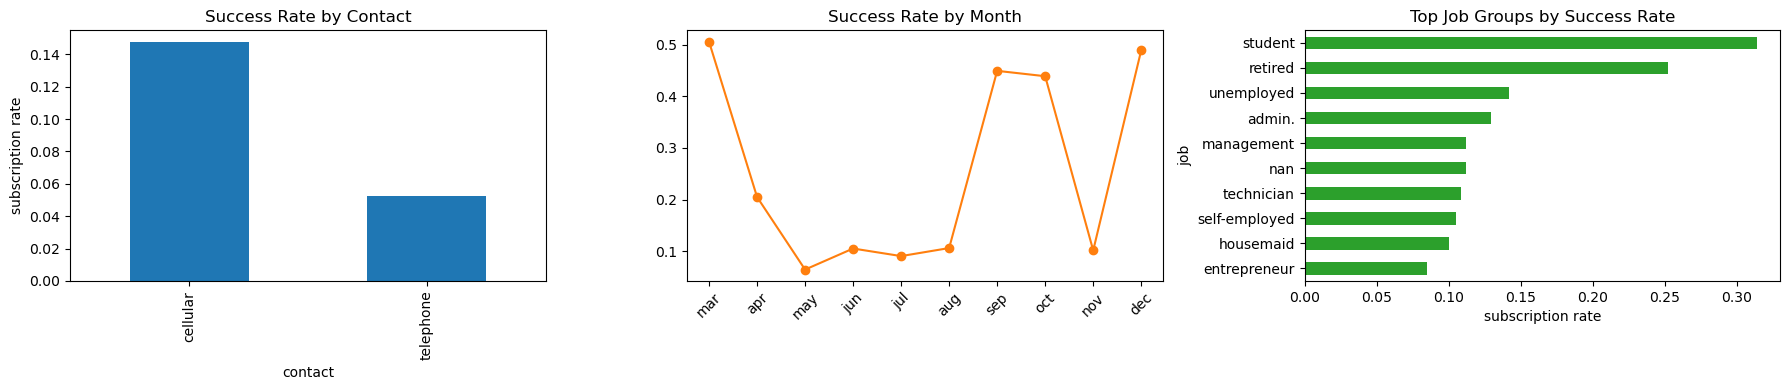

           customers  success_rate
contact                           
cellular       26144      0.147376
telephone      15044      0.052313
  month  success_rate
0   mar      0.505495
1   apr      0.204787
2   may      0.064347
3   jun      0.105115
4   jul      0.090466
5   aug      0.106021
6   sep      0.449123
7   oct      0.438719
8   nov      0.101439
9   dec      0.489011


In [4]:
contact_summary = (
    df.groupby("contact")
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
    .sort_values("success_rate", ascending=False)
)

month_summary = (
    df.groupby("month", observed=False)
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
    .reset_index()
    .sort_values("month")
)

job_summary = (
    df.groupby("job", dropna=False)
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
    .query("customers >= 200")
    .sort_values("success_rate", ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

contact_summary["success_rate"].plot(kind="bar", ax=axes[0], color="#1f77b4", title="Success Rate by Contact")
axes[0].set_ylabel("subscription rate")

axes[1].plot(month_summary["month"].astype(str), month_summary["success_rate"], marker="o", color="#ff7f0e")
axes[1].set_title("Success Rate by Month")
axes[1].tick_params(axis="x", rotation=45)

job_summary.head(10)["success_rate"].sort_values().plot(kind="barh", ax=axes[2], color="#2ca02c", title="Top Job Groups by Success Rate")
axes[2].set_xlabel("subscription rate")

plt.tight_layout()
plt.show()

print(contact_summary)
print(month_summary[["month", "success_rate"]])


## 10. 详细例子四：顺着现象继续追问，而不是停在图表表面

EDA 只是起点。更接近真实工作的动作是：根据上一步的结果继续追问。

### 示例提示词

```text
从前面的结果看，不同 contact 方式和月份的订阅率差异明显。
请继续帮我做 3 个诊断：
1. 比较 contacted_before 和 poutcome 对订阅率的影响
2. 比较不同 age_group 与 contact 方式组合的订阅率
3. 比较不同 campaign_bucket 的订阅率变化
同时请提醒我哪些字段可能存在目标泄漏风险。
```

这里的重点是让 AI 帮你 drill-down，而不是只生成漂亮图。

In [5]:
previous_contact_summary = (
    df.groupby(["contacted_before", "poutcome"])
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
    .sort_values(["success_rate", "customers"], ascending=[False, False])
)

age_contact_summary = (
    df.groupby(["age_group", "contact"], observed=False)
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
    .reset_index()
)

campaign_summary = (
    df.groupby("campaign_bucket", observed=False)
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
    .reset_index()
)

age_contact_pivot = age_contact_summary.pivot(index="age_group", columns="contact", values="success_rate")

print("previous contact effect:")
print(previous_contact_summary.head(10))

print("\nage x contact pivot:")
print(age_contact_pivot.round(3))

print("\ncampaign bucket summary:")
print(campaign_summary)

print("\nleakage warning: duration is strongly predictive, but it is only known after the call finishes.")


previous contact effect:
                              customers  success_rate
contacted_before poutcome                            
True             success           1373      0.651129
                 failure            142      0.514085
False            failure           4110      0.129440
                 nonexistent      35563      0.088322

age x contact pivot:
contact    cellular  telephone
age_group                     
18-25         0.258      0.084
26-35         0.149      0.055
36-45         0.112      0.046
46-55         0.113      0.044
56-65         0.203      0.061
66+           0.486      0.328

campaign bucket summary:
  campaign_bucket  customers  success_rate
0               1      17642      0.130371
1               2      10570      0.114570
2             3-5       9591      0.098321
3              6+       3385      0.054948

leakage warning: duration is strongly predictive, but it is only known after the call finishes.


## 11. 详细例子五：让 AI 主动提醒你避免目标泄漏

这个数据集特别适合讲一个很重要的分析习惯：**不要只问“哪些变量最有用”，还要问“这些变量能不能在业务决策时提前获得”**。

`duration` 就是一个典型例子：

- 如果你事后复盘通话效果，它当然有价值。
- 但如果你想在拨号前判断“该打给谁”，这个字段就不应该进入分析或建模主结论。

### 示例提示词

```text
请检查这个数据集里是否存在目标泄漏风险。
要求：
1. 先指出哪些字段可能属于事后信息
2. 区分“事前决策分析”和“事后复盘分析”能用的字段
3. 不要只从统计相关性出发，要从业务时点出发
```

这类提示词非常适合训练“分析不是只看相关性”的思维。

In [6]:
duration_bucket = pd.qcut(df["duration"], q=4, duplicates="drop")
duration_summary = (
    df.assign(duration_bucket=duration_bucket)
    .groupby("duration_bucket", observed=False)
    .agg(customers=("subscribed", "size"), success_rate=("subscribed", "mean"))
)

print(duration_summary)
print("\nInterpretation: duration is useful for post-call diagnosis, but should not drive pre-call targeting decisions.")


                 customers  success_rate
duration_bucket                         
(-0.001, 102.0]      10313      0.008436
(102.0, 180.0]       10392      0.045901
(180.0, 319.0]       10197      0.105619
(319.0, 4918.0]      10286      0.291561

Interpretation: duration is useful for post-call diagnosis, but should not drive pre-call targeting decisions.


## 12. 让 AI 帮你整理分析结论，但要区分事实和推断

到这一步，你已经有了不少结果，但还不能直接让 AI “生成汇报”。更稳的做法是要求它按 3 类内容整理：

- 已验证事实
- 待验证推断
- 下一步动作建议

### 示例提示词

```text
请基于上面的分析结果，生成一页摘要。
要求：
1. 先写已验证事实
2. 再写待验证推断
3. 最后写对营销团队的下一步建议
4. 不要把推断写成确定性结论
```

这一步的关键不是“让 AI 帮你写字”，而是“让 AI 按正确结构组织结论”。

## 13. 这个数据集为什么比前面的课程样例更适合 Day09

因为它同时具备了 Vibe Programming 在数据分析里最有价值的几种典型场景：

- 数据量更大，已经不适合手工一点点看。
- 类别变量更多，容易出现 `unknown`、顺序类别和长尾分组问题。
- 目标变量明确，方便讨论转化率、样本不平衡和分群。
- 可以自然引出业务分析、建模准备和目标泄漏这些更真实的问题。

也就是说，这一章不是在练“AI 会不会写 pandas”，而是在练：**你能不能用 AI 更快进入一个陌生而复杂的数据集**。

## 14. 数据分析场景下最常见的坑

- 让 AI 直接做模型，却没有先做数据审计。
- 把 `unknown` 当普通类别，忽略它其实代表信息缺失。
- 对 `month` 这种有顺序的字段按字母排序。
- 只看总体均值，不看样本量。
- 看到 `duration` 很有效，就直接把它当成前置决策依据。
- 让 AI 输出了很多图，但没有把图绑定到问题。
- 把 AI 的总结当成最终结论，而没有回查代码和口径。

在复杂数据集里，AI 的价值不是替你下判断，而是替你更快暴露风险和展开分析。

## 15. 课堂练习

### 练习 1：改写提示词
把本章“数据审计”的提示词再改进一版，要求 AI 额外检查高基数列和不平衡目标问题。

### 练习 2：追加一个业务问题
让 AI 分析 `marital`、`education`、`housing` 三个字段和订阅率之间的关系，但要求它同时输出样本量。

### 练习 3：避免误导性结论
要求 AI 生成一个“不能直接用于前置营销决策的字段列表”，并解释原因。

### 练习 4：摘要重写
先让 AI 写一版分析摘要，再由你手动改成更谨慎、更像真实业务汇报的版本。

## 16. 本章总结

这一章的重点不是学一个新库，而是学一种面对复杂数据集的工作方式：

- 先让 AI 帮你快速建立数据认知。
- 再让 AI 帮你写清洗和特征整理代码。
- 再让 AI 生成和问题绑定的 EDA。
- 最后继续追问、识别风险、整理表达。

如果前 8 天是在学“怎么做数据分析”，那么 Day09 是在学：**怎么用 AI 更高效地做更真实的数据分析**。